In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv("../data/aapl_features.csv")

In [3]:
future_steps = 5

data["Future_Close"] = data["Close"].shift(-future_steps)

In [4]:
data["Price_Change"] = (
    data["Future_Close"] - data["Close"]
)

In [5]:
threshold = 0.001

In [6]:
conditions = [
    data["Price_Change"] > threshold,
    data["Price_Change"] < -threshold
]

choices = ["UP", "DOWN"]

data["Label"] = np.select(
    conditions,
    choices,
    default="NEUTRAL"
)

In [7]:
print(data[["Close", "Future_Close", "Price_Change", "Label"]].head(10))

        Close  Future_Close  Price_Change Label
0  295.855011    295.760010     -0.095001  DOWN
1  295.709991    296.125000      0.415009    UP
2  295.790009    296.289001      0.498993    UP
3  296.030090    296.290009      0.259918    UP
4  295.839996    296.179993      0.339996    UP
5  295.760010    295.250000     -0.510010  DOWN
6  296.125000    295.600006     -0.524994  DOWN
7  296.289001    295.427490     -0.861511  DOWN
8  296.290009    295.385010     -0.904999  DOWN
9  296.179993    295.339996     -0.839996  DOWN


In [8]:
label_map = {
    "DOWN": 0,
    "NEUTRAL": 1,
    "UP": 2
}

data["Label_Encoded"] = data["Label"].map(label_map)

In [9]:
data = data.dropna()

In [10]:
print(data["Label"].value_counts())

Label
UP         201
DOWN       157
NEUTRAL      2
Name: count, dtype: int64


<Axes: xlabel='Label'>

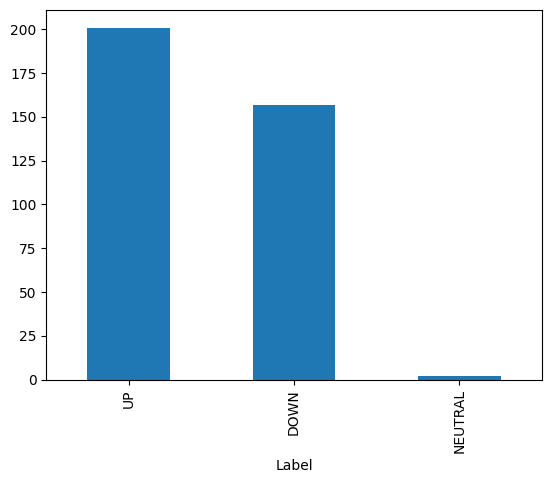

In [11]:
data["Label"].value_counts().plot(kind="bar")

In [12]:
data.to_csv("../data/aapl_final_dataset.csv", index=False)